<a href="https://colab.research.google.com/github/MariaMuu/Creatine-Simulation-Analysis/blob/main/Cleaned_creatine_synthetic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Important libraries

In [53]:
import pandas as pd
import numpy as np

In [54]:
df_initial = pd.read_csv('/content/synthetic_creatine_study.csv')

### Initial exploration

In [55]:
df_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             788 non-null    object 
 1   age              792 non-null    float64
 2   sex              791 non-null    object 
 3   dose_g           791 non-null    float64
 4   sleep_score      792 non-null    float64
 5   mood_score       792 non-null    float64
 6   cognition_score  791 non-null    float64
dtypes: float64(5), object(2)
memory usage: 45.7+ KB


In [56]:
# show the first 50 rows

df_initial.head(20)

,name,age,sex,dose_g,sleep_score,mood_score,cognition_score
0,Vasileios Karagiannis,28.0,male,14.285214,7.505528,67.122028,115.977027
1,Christos Georgiou,39.0,male,13.078266,5.341051,59.524379,106.545224
2,Christos Georgiou,36.0,male,5.446547,6.274310,59.882594,92.989228
3,Alexandra Dimopoulos,30.0,NaN,25.468375,5.943014,65.241407,113.689930
4,Vasiliki Konstantinidis,50.0,female,10.258739,6.839209,66.517821,96.246922
5,Anastasios Ioannidis,64.0,male,16.955851,6.828478,63.171471,103.036039
6,Evangelia Ioannidis,41.0,female,29.753709,6.557338,79.521047,121.204846
7,Dimitra Dimopoulos,40.0,female,15.806020,6.258968,75.295466,100.670915
8,Anastasios Dimopoulos,44.0,male,6.461365,7.090825,56.661634,103.350907
9,NaN,33.0,female,13.658044,7.357442,66.392850,105.381263


In [57]:
# show the last 50 rows

df_initial.tail(20)

,name,age,sex,dose_g,sleep_score,mood_score,cognition_score
813,Dimitra Pappas,58.0,female,7.102456,5.171608,43.810135,103.475864
814,Dimitrios Dimopoulos,60.0,male,25.238249,5.962337,60.398772,105.208612
815,Anastasios Georgiou,38.0,male,14.599097,5.974804,56.790394,103.292576
816,Spyridon Dimopoulos,39.0,male,24.750339,8.290074,NaN,117.505818
817,NaN,33.0,male,21.165148,6.379671,NaN,107.226370
818,Vasileios Dimopoulos,36.0,male,7.554840,5.774393,57.191205,109.526083
819,Anastasia Georgiou,19.0,female,7.577344,5.858787,NaN,96.363126
820,Evangelia Georgiou,35.0,female,8.742599,5.768660,55.508179,102.456215
821,Spyridon Karagiannis,40.0,male,8.866804,4.067726,69.742016,102.942214
822,Georgios Adamidis,51.0,male,6.624660,5.304668,56.964045,98.828282


###Removing names for GDPR reasons, not necessary to do data masking or pseudoanymization

In [58]:
df = df_initial.drop(['name'], axis = 1 )
df

,age,sex,dose_g,sleep_score,mood_score,cognition_score
0,28.0,male,14.285214,7.505528,67.122028,115.977027
1,39.0,male,13.078266,5.341051,59.524379,106.545224
2,36.0,male,5.446547,6.274310,59.882594,92.989228
3,30.0,NaN,25.468375,5.943014,65.241407,113.689930
4,50.0,female,10.258739,6.839209,66.517821,96.246922
...,...,...,...,...,...,...
828,27.0,male,8.479951,7.024969,70.177010,99.979841
829,24.0,female,13.430678,5.353932,72.435327,118.864323
830,43.0,female,9.422179,7.512902,60.233227,102.974477
831,47.0,female,NaN,7.571448,67.469846,113.014602


### Rename 'dose_g' column to 'creatine_dose_g'

In [59]:
df.rename(columns = {'dose_g': 'creatine_dose_g'}, inplace = True)
df

,age,sex,creatine_dose_g,sleep_score,mood_score,cognition_score
0,28.0,male,14.285214,7.505528,67.122028,115.977027
1,39.0,male,13.078266,5.341051,59.524379,106.545224
2,36.0,male,5.446547,6.274310,59.882594,92.989228
3,30.0,NaN,25.468375,5.943014,65.241407,113.689930
4,50.0,female,10.258739,6.839209,66.517821,96.246922
...,...,...,...,...,...,...
828,27.0,male,8.479951,7.024969,70.177010,99.979841
829,24.0,female,13.430678,5.353932,72.435327,118.864323
830,43.0,female,9.422179,7.512902,60.233227,102.974477
831,47.0,female,NaN,7.571448,67.469846,113.014602


### Round creatine values

In [60]:
df['creatine_dose_g'] = df['creatine_dose_g'].round()
df

,age,sex,creatine_dose_g,sleep_score,mood_score,cognition_score
0,28.0,male,14.0,7.505528,67.122028,115.977027
1,39.0,male,13.0,5.341051,59.524379,106.545224
2,36.0,male,5.0,6.274310,59.882594,92.989228
3,30.0,NaN,25.0,5.943014,65.241407,113.689930
4,50.0,female,10.0,6.839209,66.517821,96.246922
...,...,...,...,...,...,...
828,27.0,male,8.0,7.024969,70.177010,99.979841
829,24.0,female,13.0,5.353932,72.435327,118.864323
830,43.0,female,9.0,7.512902,60.233227,102.974477
831,47.0,female,NaN,7.571448,67.469846,113.014602


### Check for duplicates and remove them

In [61]:
duplicates = df.duplicated().sum()
print(f'The amount of duplicates are: {duplicates}')

The amount of duplicates are: 28


In [62]:
# Display the exact duplicated rows

duplicated_rows = df[df.duplicated(keep=False)]
display(duplicated_rows)

,age,sex,creatine_dose_g,sleep_score,mood_score,cognition_score
6,41.0,female,30.0,6.557338,79.521047,121.204846
16,45.0,female,NaN,8.047819,60.862294,NaN
51,64.0,male,29.0,7.938870,81.839374,104.430632
61,32.0,female,26.0,7.159676,82.278137,113.303755
67,37.0,female,NaN,8.846633,71.866790,111.309251
74,63.0,NaN,7.0,4.700800,50.133429,102.368351
79,41.0,male,12.0,7.875786,NaN,100.659531
128,49.0,NaN,26.0,4.578968,66.050570,107.680959
129,33.0,male,28.0,7.549344,91.210374,109.059196
133,51.0,male,12.0,6.947049,59.870862,105.463931


In [63]:
# Remove duplicates

df_before = len(df)
df = df.drop_duplicates()
df_after = len(df)

print(f"Rows before removing duplicates: {df_before}")
print(f"Rows after removing duplicates: {df_after}")
print(f"Total duplicates removed: {df_before - df_after}")


Rows before removing duplicates: 833
Rows after removing duplicates: 805
Total duplicates removed: 28


### Check missing values

In [64]:
df.isnull().sum()

,0
age,41
sex,40
creatine_dose_g,40
sleep_score,41
mood_score,40
cognition_score,40


### Fill missing values in each numerical column with its median

In [65]:
# Identify numerical columns to fill missing values
numerical_cols = df.select_dtypes(include=np.number).columns

# Fill missing values in each numerical column with its median
for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled missing values in '{col}' with median: {median_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum())

Filled missing values in 'age' with median: 42.0
Filled missing values in 'creatine_dose_g' with median: 18.0
Filled missing values in 'sleep_score' with median: 6.754697895935591
Filled missing values in 'mood_score' with median: 65.6021846982301
Filled missing values in 'cognition_score' with median: 106.82610509465744

Missing values after imputation:
age                 0
sex                40
creatine_dose_g     0
sleep_score         0
mood_score          0
cognition_score     0
dtype: int64


/tmp/ipykernel_2439/3598822719.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(median_val)


### Check different unique values in the 'sex' column

In [66]:
df['sex'].unique()

array(['male', nan, 'female', 'm', 'MALE', 'M', 'F', 'FEMALE', 'f'],
      dtype=object)

In [67]:
# Convert all entries to lowercase AND strip any leading/trailing whitespace
df['sex'] = df['sex'].str.lower().str.strip()

# Define a mapping for variations using the .replace() method
# .replace() will only replace the keys specified, leaving other values (like 'male', 'female') as is.
sex_replace_map = {
    'm': 'male',
    'f': 'female'
}
df['sex'] = df['sex'].replace(sex_replace_map)

# Fill any remaining NaN values with 'unknown'
df['sex'] = df['sex'].fillna('unknown')

print("Unique values in 'sex' column after standardization and imputation:")
print(df['sex'].unique())

print("\nMissing values after 'sex' column processing:")
print(df.isnull().sum())

Unique values in 'sex' column after standardization and imputation:
['male' 'unknown' 'female']

Missing values after 'sex' column processing:
age                0
sex                0
creatine_dose_g    0
sleep_score        0
mood_score         0
cognition_score    0
dtype: int64


/tmp/ipykernel_2439/3842754271.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = df['sex'].str.lower().str.strip()
/tmp/ipykernel_2439/3842754271.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = df['sex'].replace(sex_replace_map)
/tmp/ipykernel_2439/3842754271.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [68]:
df.describe()

,age,creatine_dose_g,sleep_score,mood_score,cognition_score
count,805.000000,805.000000,805.000000,805.000000,805.000000
mean,42.408696,17.751553,6.876265,66.986988,107.956012
std,36.298352,11.176018,2.269440,30.764688,31.169355
min,5.000000,-10.000000,-5.000000,-150.000000,-100.000000
25%,30.000000,11.000000,6.123652,58.916328,103.219290
50%,42.000000,18.000000,6.754698,65.602185,106.826105
75%,52.000000,23.000000,7.428357,71.844043,110.518298
max,999.000000,250.000000,60.000000,800.000000,900.000000


### Outlier Detection using Box Plots

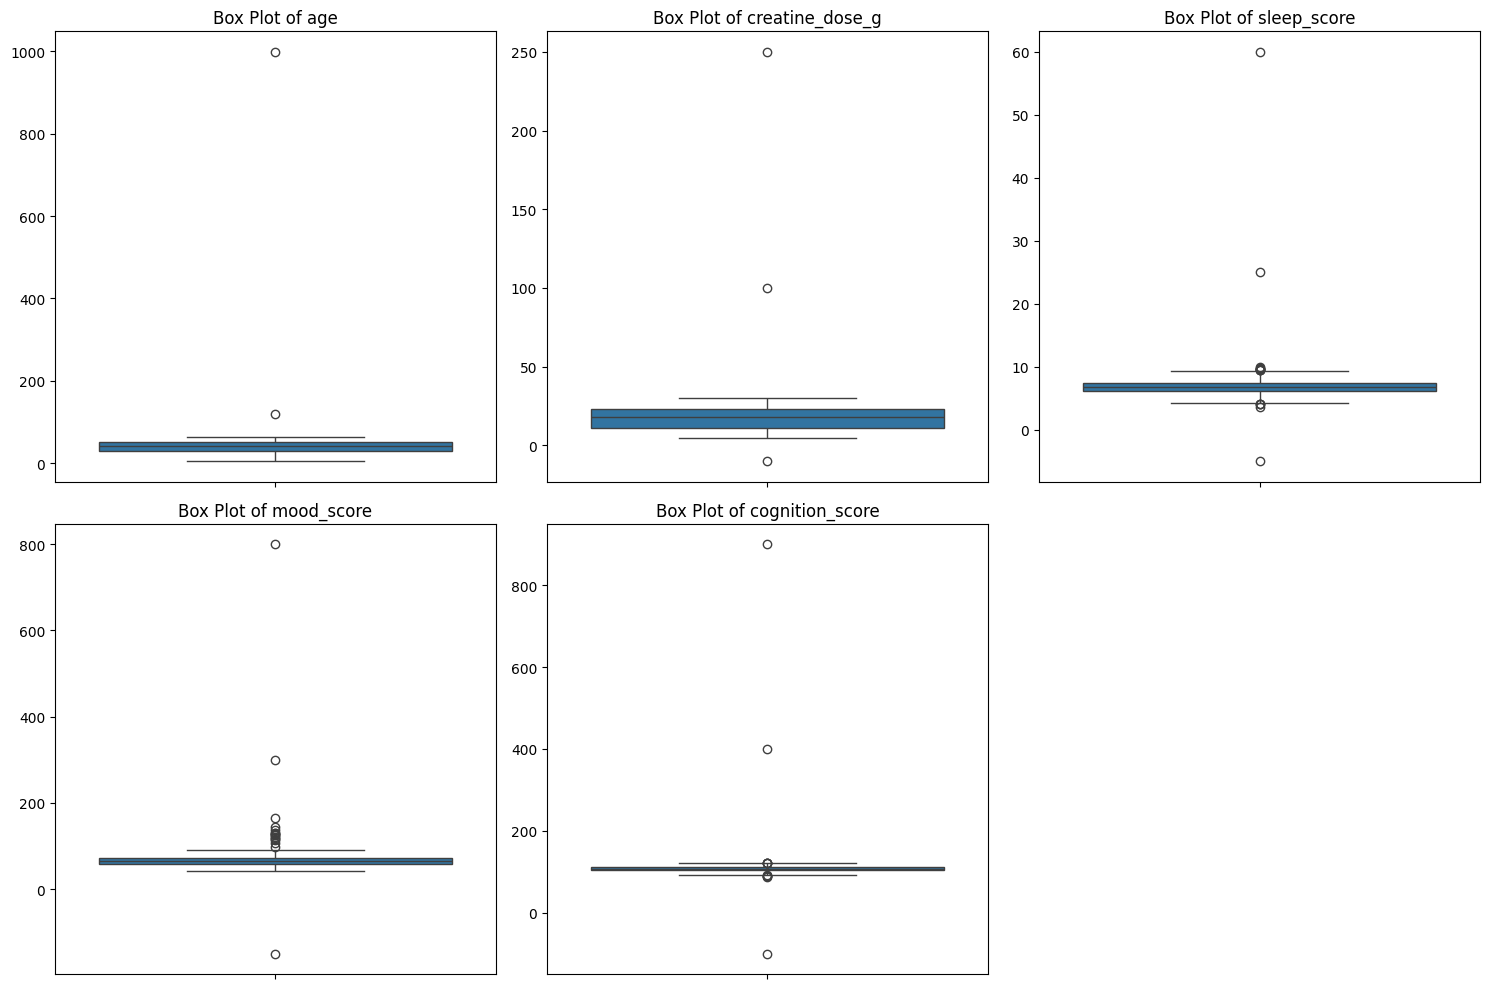

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Outlier Detection using IQR Method

In [70]:
numeric_cols = df.select_dtypes(include=np.number)

outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

print(outlier_counts)

{'age': np.int64(2), 'creatine_dose_g': np.int64(3), 'sleep_score': np.int64(15), 'mood_score': np.int64(17), 'cognition_score': np.int64(12)}


### Fill outliers in each numerical column with its median

In [71]:
df_cleaned_outliers = df.copy() # Create a copy to store the changes

# Get all numerical columns
numerical_cols = df_cleaned_outliers.select_dtypes(include=np.number).columns

# Loop through each numerical column to find and fill outliers with its median
for col in numerical_cols:
    Q1 = df_cleaned_outliers[col].quantile(0.25)
    Q3 = df_cleaned_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median_val = df_cleaned_outliers[col].median()

    # Identify outliers using the IQR method
    outliers_iqr = (df_cleaned_outliers[col] < lower_bound) | (df_cleaned_outliers[col] > upper_bound)

    # Count identified outliers
    num_outliers = outliers_iqr.sum()

    if num_outliers > 0:
        # Replace values below the lower bound or above the upper bound with the median
        df_cleaned_outliers.loc[outliers_iqr, col] = median_val
        print(f"Filled {num_outliers} outliers in '{col}' with median: {median_val}")
    else:
        print(f"No outliers found or filled in '{col}'.")

print("\n---")

print("Descriptive statistics AFTER outlier imputation:\n")
print(df_cleaned_outliers[numerical_cols].describe())

# Update df_new with the cleaned DataFrame
df_new = df_cleaned_outliers.copy()

Filled 2 outliers in 'age' with median: 42.0
Filled 3 outliers in 'creatine_dose_g' with median: 18.0
Filled 15 outliers in 'sleep_score' with median: 6.754697895935591
Filled 17 outliers in 'mood_score' with median: 65.6021846982301
Filled 12 outliers in 'cognition_score' with median: 106.82610509465744

---
Descriptive statistics AFTER outlier imputation:

              age  creatine_dose_g  sleep_score  mood_score  cognition_score
count  805.000000       805.000000   805.000000  805.000000       805.000000
mean    41.122981        17.396273     6.787820   65.005146       106.893336
std     13.049314         6.951018     0.965429    9.144346         5.218334
min      5.000000         5.000000     4.169936   40.718408        92.688674
25%     30.000000        11.000000     6.128446   58.922736       103.321328
50%     42.000000        18.000000     6.754698   65.602185       106.826105
75%     52.000000        23.000000     7.389322   70.991288       110.395342
max     64.000000      

### Replace ages < 18 with overall age median

In [72]:
# 1. Calculate the median from the valid adult population (18+)
df_median_age = df[df['age'] >= 18]['age'].median()

# 2. Identify the rows where age is logically too low (e.g., age 5)
age_to_replace = (df['age'] < 18)

# 3. Replace those specific values with the overall median
df.loc[age_to_replace, 'age'] = df_median_age

print(f"Median age used for replacement: {df_median_age}")
print(f"The DataFrame has been updated. New minimum age: {df['age'].min()}")
display(df.describe())


Median age used for replacement: 42.0
The DataFrame has been updated. New minimum age: 18.0


,age,creatine_dose_g,sleep_score,mood_score,cognition_score
count,805.000000,805.000000,805.000000,805.000000,805.000000
mean,42.454658,17.751553,6.876265,66.986988,107.956012
std,36.274342,11.176018,2.269440,30.764688,31.169355
min,18.000000,-10.000000,-5.000000,-150.000000,-100.000000
25%,30.000000,11.000000,6.123652,58.916328,103.219290
50%,42.000000,18.000000,6.754698,65.602185,106.826105
75%,52.000000,23.000000,7.428357,71.844043,110.518298
max,999.000000,250.000000,60.000000,800.000000,900.000000


In [73]:
df.to_csv("cleaned_synthetic_creatine_study.csv", index=False)